<a href="https://colab.research.google.com/github/juansanabria0607/DataJam/blob/main/TablaZonasConMasAccidentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install folium -q

from google.colab import files
uploaded = files.upload()

Saving ACCIDENTE.xlsx to ACCIDENTE.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap

df = pd.read_excel("ACCIDENTE.xlsx")

df["lat"] = df["LATITUD"] / 1e8
df["lon"] = df["LONGITUD"] / 1e8
df.loc[df["lat"] < 1, "lat"] = df.loc[df["lat"] < 1, "lat"] * 10

df_av = df[
    (df["MVINOMBRE"].str.startswith("AVENIDA", na=False)) &
    (df["lat"].between(4.4, 5.0)) &
    (df["lon"].between(-74.5, -73.5))
].copy()

print(f"Accidentes en avenidas: {len(df_av):,} registros")
print(df_av["MVINOMBRE"].value_counts().head(10))

Accidentes en avenidas: 377,471 registros
MVINOMBRE
AVENIDA BOYACA                       37307
AVENIDA CIUDAD DE CALI               22384
AVENIDA PASEO DE LOS LIBERTADORES    19818
AVENIDA ALBERTO LLERAS CAMARGO       18813
AVENIDA CIUDAD DE QUITO              16871
AVENIDA MEDELLIN                     14867
AVENIDA CENTENARIO                   13552
AVENIDA CARACAS                      13436
AVENIDA DEL CONGRESO EUCARISTICO     13019
AVENIDA DE LAS AMERICAS              12942
Name: count, dtype: int64


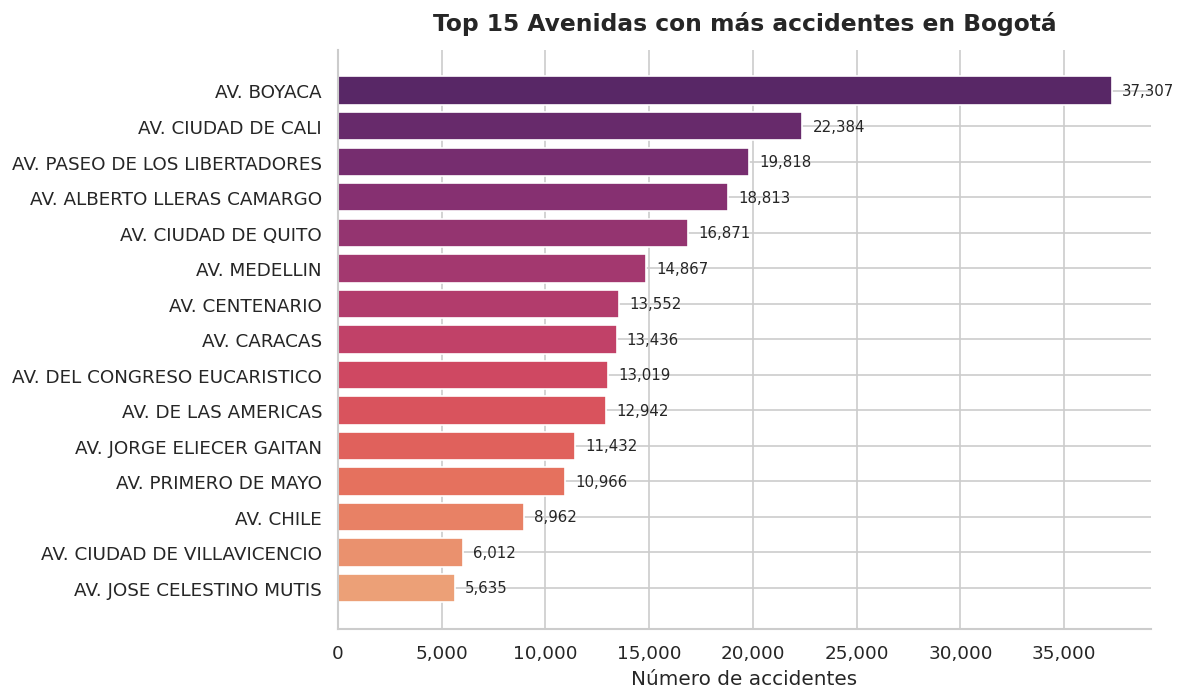

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

top_av = df_av["MVINOMBRE"].value_counts().head(15).sort_values()
top_av.index = top_av.index.str.replace("AVENIDA ", "AV. ", regex=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores = sns.color_palette("flare", len(top_av))
bars = ax.barh(top_av.index, top_av.values, color=colores)
ax.bar_label(bars, fmt="{:,.0f}", padding=6, fontsize=9)
ax.set_title("Top 15 Avenidas con más accidentes en Bogotá", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Número de accidentes")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.show()